### RAG System: QA with PDF

QA with PDF RAG means using a Question Answering (QA) system powered by Retrieval-Augmented Generation (RAG) on PDF documents. Let’s break it down:

**Key Concepts**

• 	**PDF ingestion**: You load one or more PDF files into your pipeline. The text is extracted and chunked into manageable pieces (e.g., paragraphs or sections).

• 	**Vectorization**: Each chunk is converted into embeddings (numerical representations of meaning) using a model like OpenAI, Hugging Face, or similar.

• 	**Retrieval**: When a user asks a question, the system searches the vector database for the most relevant chunks from the PDF.

• 	**Generation (RAG)**: The retrieved chunks are passed to a language model, which uses them to generate a grounded answer. This ensures the response is based on the actual PDF content rather than hallucinations.

**Workflow**

1. 	Load PDF → Extract text.
2. 	Chunk text → Split into smaller sections.
3. 	Embed chunks → Store embeddings in a vector database (e.g., FAISS, Pinecone, Chroma).
4. 	User asks a question → Convert question into an embedding.
5. 	Retrieve relevant chunks → Find the closest matches in the vector DB.
6. 	Generate answer → Pass retrieved text + question into the LLM to produce a coherent answer.

In [1]:
# HF environmental variable

import os
from dotenv import load_dotenv
load_dotenv()

os.environ["HUGGINGFACE_API_KEY"] = os.getenv("HUGGINGFACE_API_KEY")

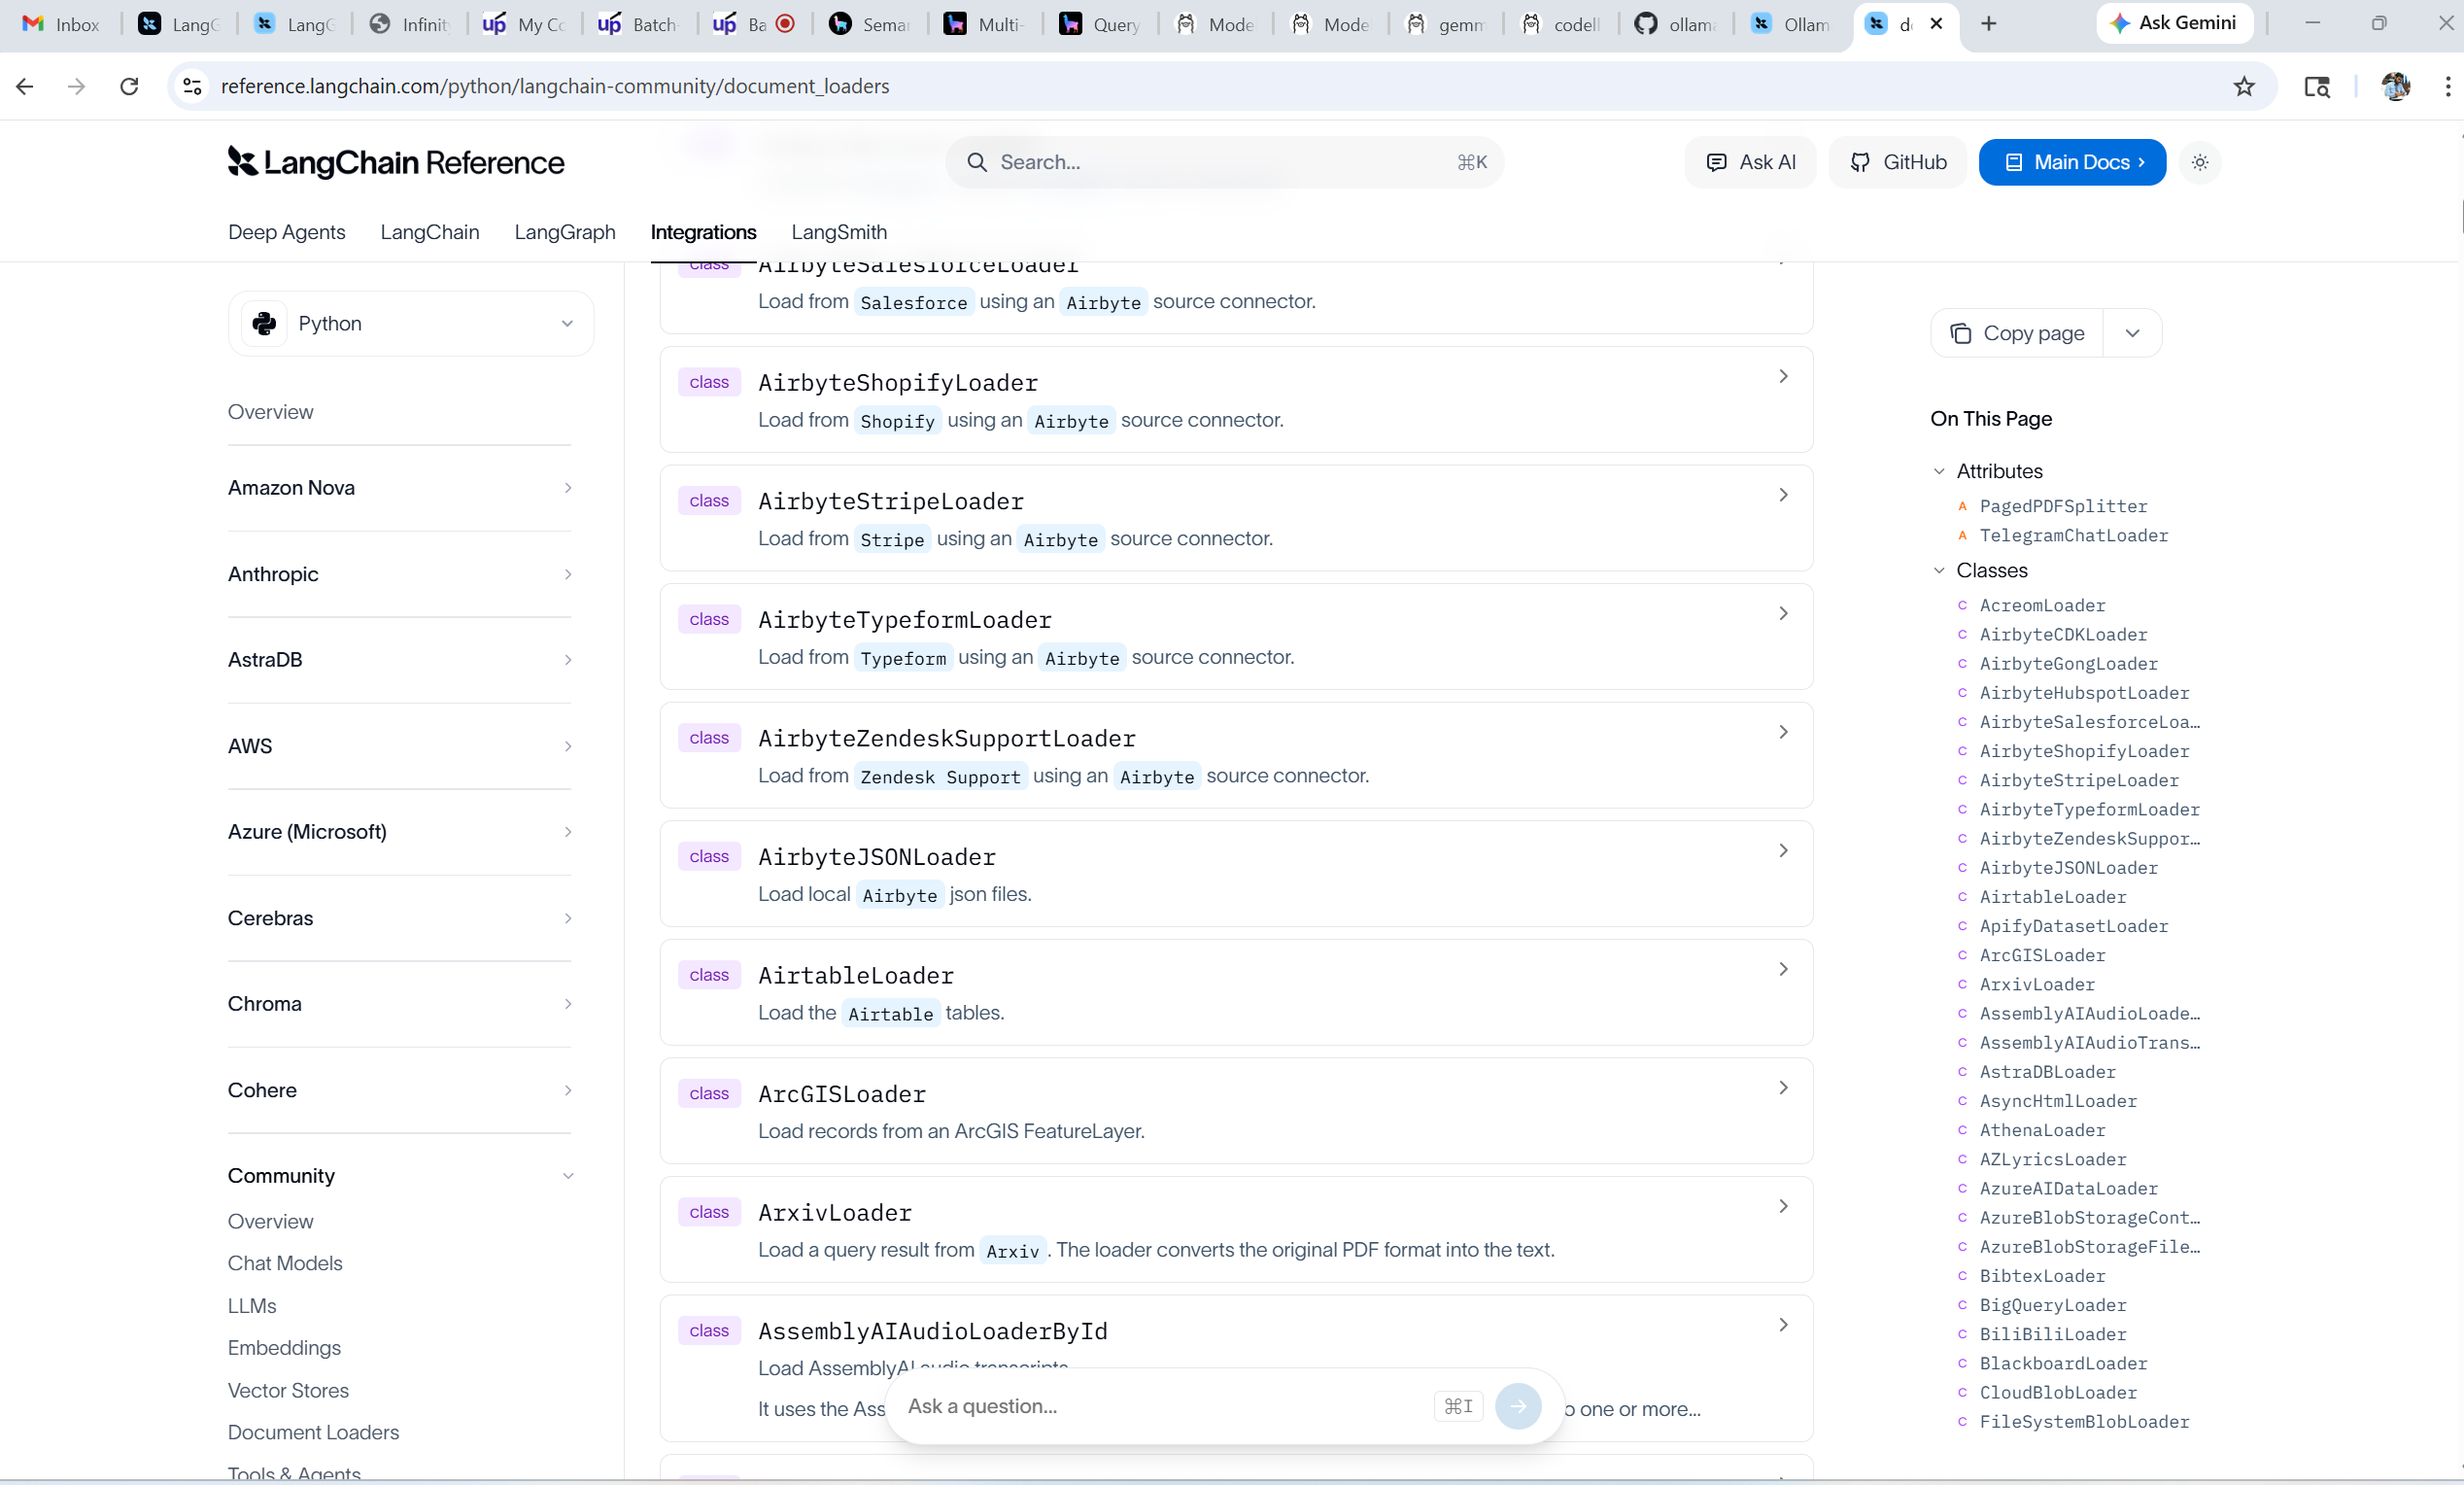

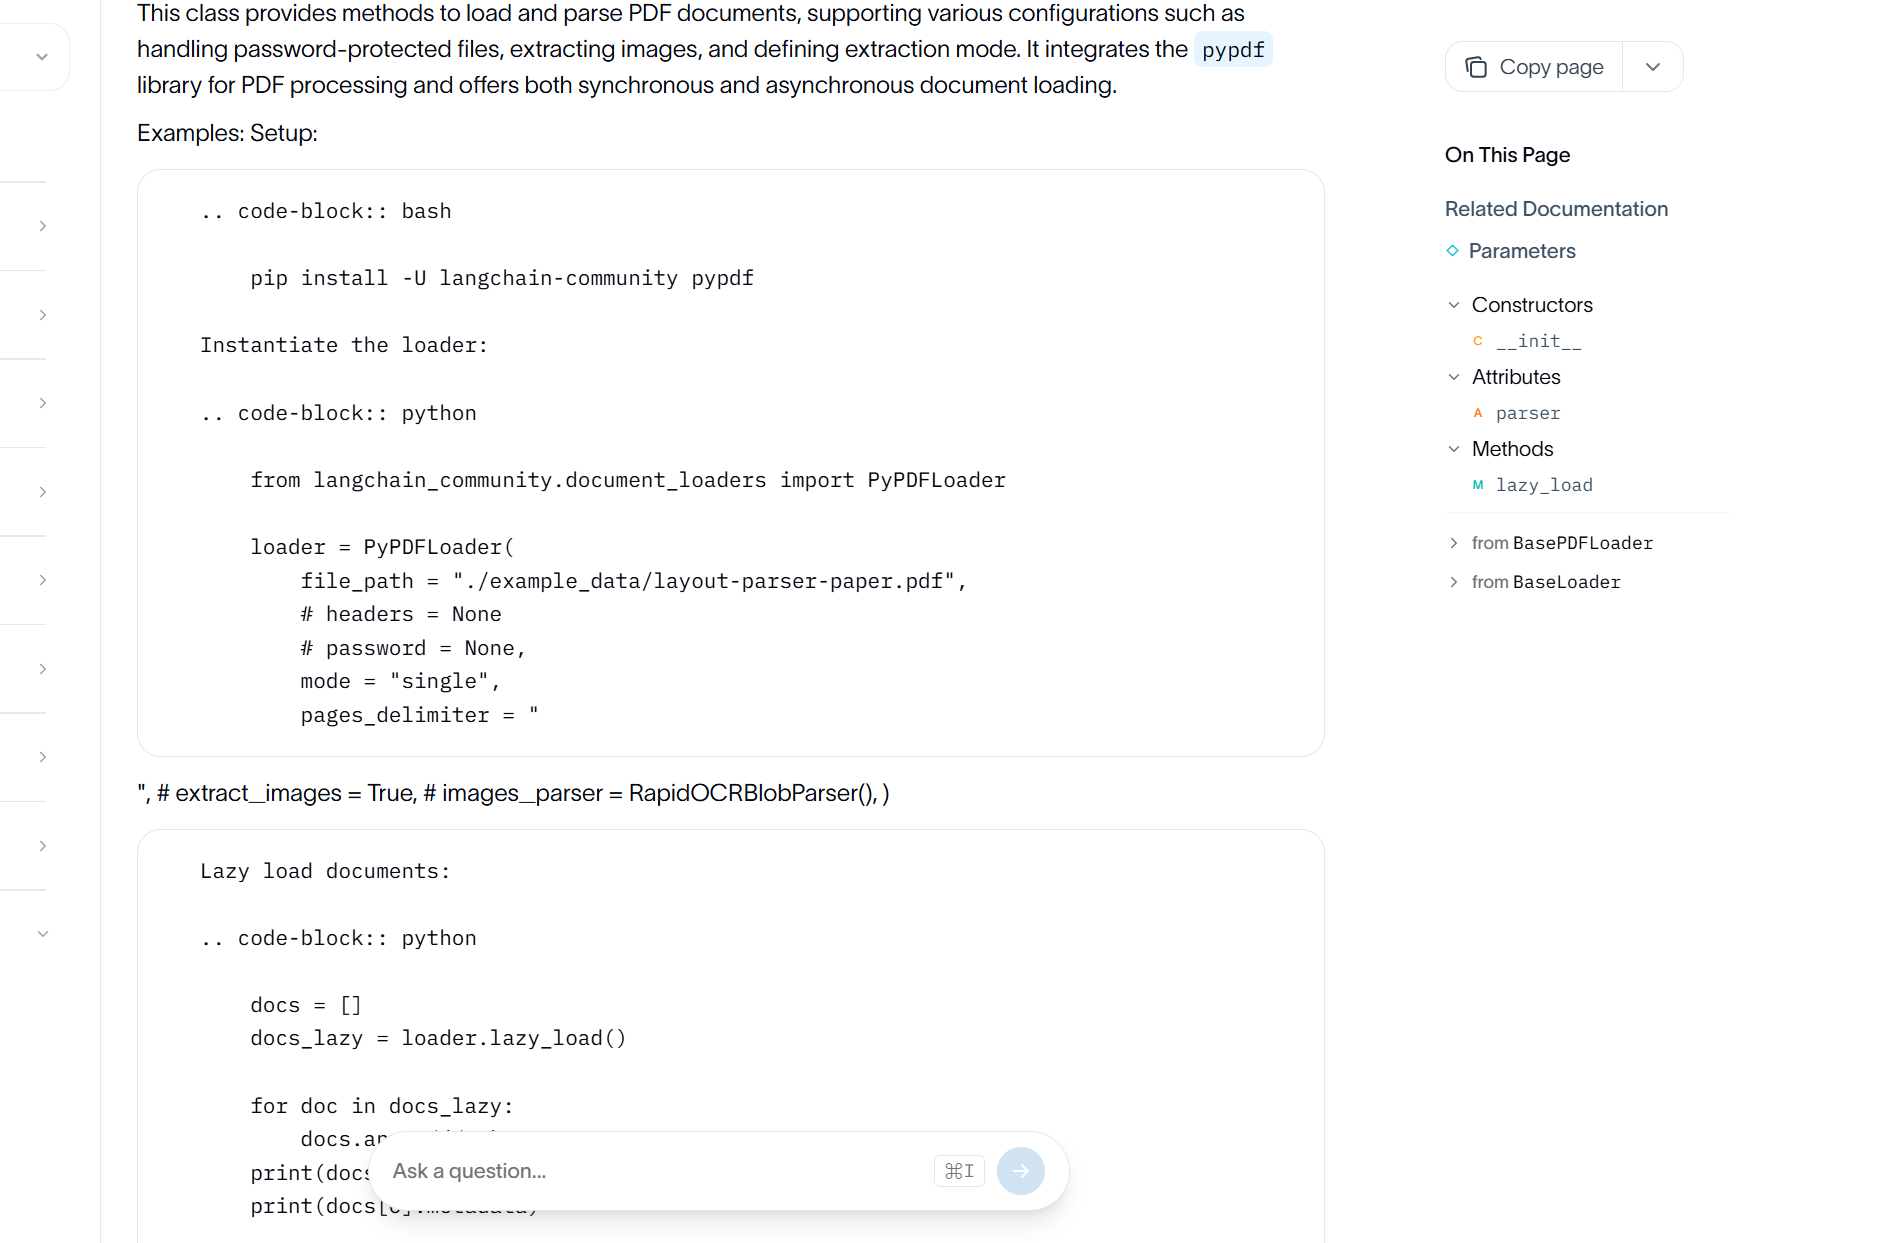

In [2]:
# Depencancies
from langchain_community.document_loaders import PyPDFLoader

d:\GENAIBatch\langchain_new\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# My PDF Path

doc_path = "D:\\GENAIBatch\\langchain_new\\RAG\\PEFT2312.12148v1.pdf"
print(doc_path)

D:\GENAIBatch\langchain_new\RAG\PEFT2312.12148v1.pdf


In [4]:
# To read this file I will use the langchain document load that will load this document in standard format - langchain document - page and metadata

loader = PyPDFLoader(doc_path)
loader

In [5]:
# load the doc

docs = loader.load()
docs

[Document(metadata={'producer': 'pdfTeX-1.40.25', 'creator': 'LaTeX with hyperref', 'creationdate': '2023-12-20T02:07:04+00:00', 'author': '', 'keywords': '', 'moddate': '2023-12-20T02:07:04+00:00', 'ptex.fullbanner': 'This is pdfTeX, Version 3.141592653-2.6-1.40.25 (TeX Live 2023) kpathsea version 6.3.5', 'subject': '', 'title': '', 'trapped': '/False', 'source': 'D:\\GENAIBatch\\langchain_new\\RAG\\PEFT2312.12148v1.pdf', 'total_pages': 20, 'page': 0, 'page_label': '1'}, page_content='1\nParameter-Efficient Fine-Tuning Methods for\nPretrained Language Models: A Critical\nReview and Assessment\nLingling Xu, Haoran Xie, Si-Zhao Joe Qin, Xiaohui Tao, Fu Lee Wang\nAbstract—With the continuous growth in the number of\nparameters of transformer-based pretrained language models\n(PLMs), particularly the emergence of large language models\n(LLMs) with billions of parameters, many natural language\nprocessing (NLP) tasks have demonstrated remarkable success.\nHowever, the enormous size and com

In [6]:
# To read this 
import pprint

print("Metadata:")
pprint.pp(docs[0].metadata)
print("-"*25)
print("Page Content:")
pprint.pp(docs[0].page_content)

Metadata:
{'producer': 'pdfTeX-1.40.25',
 'creator': 'LaTeX with hyperref',
 'creationdate': '2023-12-20T02:07:04+00:00',
 'author': '',
 'keywords': '',
 'moddate': '2023-12-20T02:07:04+00:00',
 'ptex.fullbanner': 'This is pdfTeX, Version 3.141592653-2.6-1.40.25 (TeX Live '
                    '2023) kpathsea version 6.3.5',
 'subject': '',
 'title': '',
 'trapped': '/False',
 'source': 'D:\\GENAIBatch\\langchain_new\\RAG\\PEFT2312.12148v1.pdf',
 'total_pages': 20,
 'page': 0,
 'page_label': '1'}
-------------------------
Page Content:
('1\n'
 'Parameter-Efficient Fine-Tuning Methods for\n'
 'Pretrained Language Models: A Critical\n'
 'Review and Assessment\n'
 'Lingling Xu, Haoran Xie, Si-Zhao Joe Qin, Xiaohui Tao, Fu Lee Wang\n'
 'Abstract—With the continuous growth in the number of\n'
 'parameters of transformer-based pretrained language models\n'
 '(PLMs), particularly the emergence of large language models\n'
 '(LLMs) with billions of parameters, many natural language\n'
 'proces

In [7]:
# Split the documents in manageable chunks

from langchain_text_splitters import RecursiveCharacterTextSplitter

splitter = RecursiveCharacterTextSplitter(
    chunk_size = 300,
    chunk_overlap = 50
)

doc_chunks = splitter.split_documents(docs)

In [8]:
doc_chunks

[Document(metadata={'producer': 'pdfTeX-1.40.25', 'creator': 'LaTeX with hyperref', 'creationdate': '2023-12-20T02:07:04+00:00', 'author': '', 'keywords': '', 'moddate': '2023-12-20T02:07:04+00:00', 'ptex.fullbanner': 'This is pdfTeX, Version 3.141592653-2.6-1.40.25 (TeX Live 2023) kpathsea version 6.3.5', 'subject': '', 'title': '', 'trapped': '/False', 'source': 'D:\\GENAIBatch\\langchain_new\\RAG\\PEFT2312.12148v1.pdf', 'total_pages': 20, 'page': 0, 'page_label': '1'}, page_content='1\nParameter-Efficient Fine-Tuning Methods for\nPretrained Language Models: A Critical\nReview and Assessment\nLingling Xu, Haoran Xie, Si-Zhao Joe Qin, Xiaohui Tao, Fu Lee Wang\nAbstract—With the continuous growth in the number of\nparameters of transformer-based pretrained language models'),
 Document(metadata={'producer': 'pdfTeX-1.40.25', 'creator': 'LaTeX with hyperref', 'creationdate': '2023-12-20T02:07:04+00:00', 'author': '', 'keywords': '', 'moddate': '2023-12-20T02:07:04+00:00', 'ptex.fullbanne

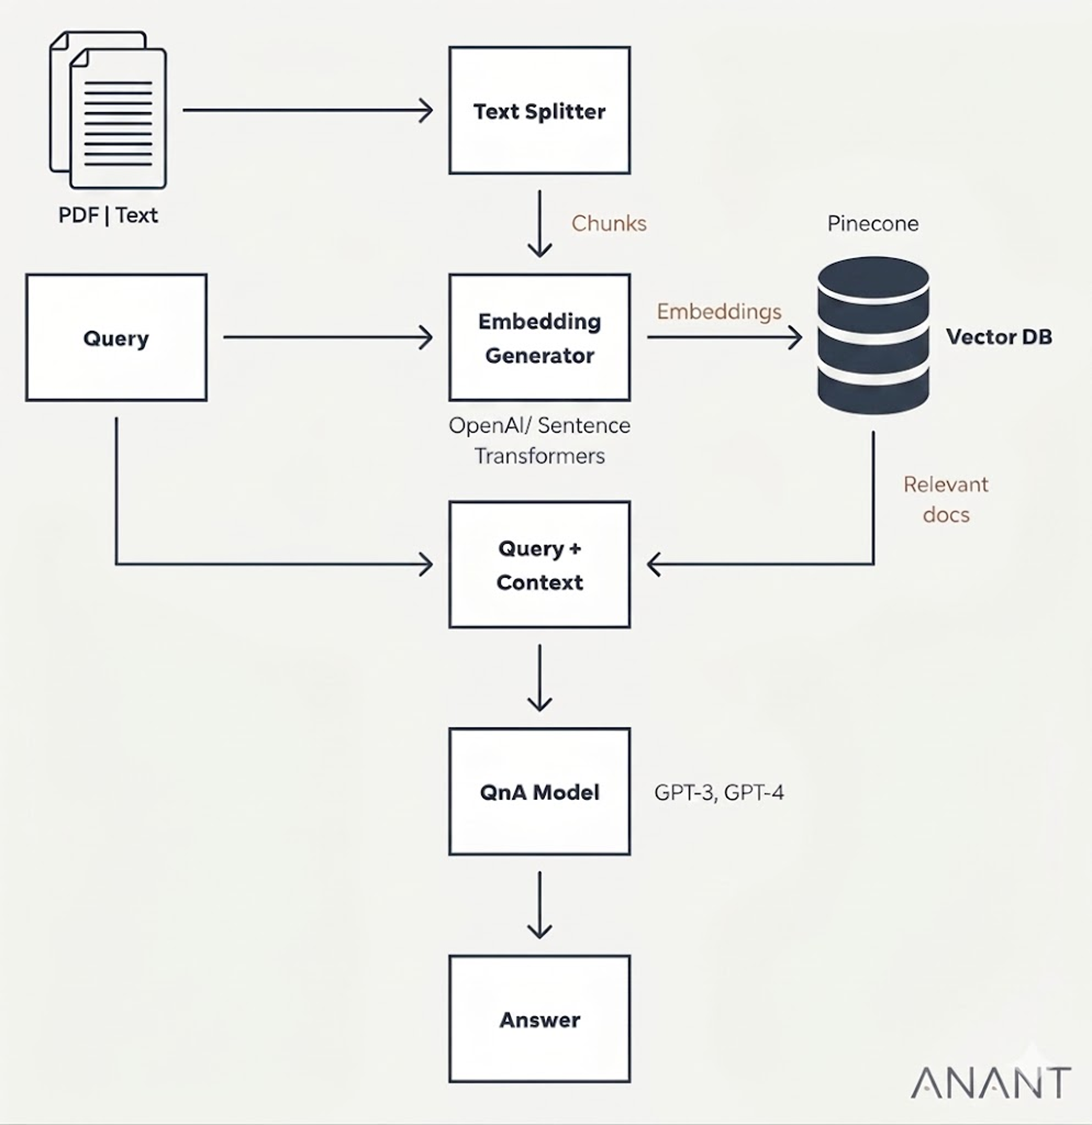

In [9]:
# check somethings

doc_chunks[5].page_content

'latest advancements and practical applications, this survey serves\nas an invaluable resource for researchers and practitioners\nseeking to navigate the challenges and opportunities presented\nby PEFT in the context of PLMs.\nIndex Terms—Parameter-efficient, fine-tuning, pretrained lan-'

In [10]:
doc_chunks[5].metadata

{'producer': 'pdfTeX-1.40.25',
 'creator': 'LaTeX with hyperref',
 'creationdate': '2023-12-20T02:07:04+00:00',
 'author': '',
 'keywords': '',
 'moddate': '2023-12-20T02:07:04+00:00',
 'ptex.fullbanner': 'This is pdfTeX, Version 3.141592653-2.6-1.40.25 (TeX Live 2023) kpathsea version 6.3.5',
 'subject': '',
 'title': '',
 'trapped': '/False',
 'source': 'D:\\GENAIBatch\\langchain_new\\RAG\\PEFT2312.12148v1.pdf',
 'total_pages': 20,
 'page': 0,
 'page_label': '1'}

In [11]:
# Let's do the embedding

from langchain_huggingface import HuggingFaceEmbeddings
from langchain_community.vectorstores import FAISS


embeddings = HuggingFaceEmbeddings(model_name="sentence-transformers/all-MiniLM-L6-v2")
vectordb = FAISS.from_documents(doc_chunks, embeddings)

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 4653.71it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


- Here I have used HuggingFaceEmbeddings from langchain to load llm for creating embeddings.
- This loads the **MiniLM sentence transformer from Hugging Face**.
- It's lightweight, fast, and very accurate for semantic search.
- Converts each text chunk into a 768-dimensional vector that captures its meaning.
- Converts all the doc_chunks into embeddings using the model.
- Stores them in a FAISS index, which supports fast nearest neighbor search.
- Returns a vectordb object that you can query later.
- Many VectorDB - FAISS, CromaDB, pinecone etc

In [12]:
print(f"Stored {vectordb.index.ntotal} chunks in the FAISS vector store.")

Stored 454 chunks in the FAISS vector store.


In [13]:
# Perform the similarity search 

vectordb.similarity_search("What is Ladder Side-Tuning?")

[Document(id='29add3b7-d917-40ed-941a-6683d779a61c', metadata={'producer': 'pdfTeX-1.40.25', 'creator': 'LaTeX with hyperref', 'creationdate': '2023-12-20T02:07:04+00:00', 'author': '', 'keywords': '', 'moddate': '2023-12-20T02:07:04+00:00', 'ptex.fullbanner': 'This is pdfTeX, Version 3.141592653-2.6-1.40.25 (TeX Live 2023) kpathsea version 6.3.5', 'subject': '', 'title': '', 'trapped': '/False', 'source': 'D:\\GENAIBatch\\langchain_new\\RAG\\PEFT2312.12148v1.pdf', 'total_pages': 20, 'page': 17, 'page_label': '18'}, page_content='[29] Y .-L. Sung, J. Cho, and M. Bansal, “LST: Ladder side-tuning for\nparameter and memory efficient transfer learning,” inProc. Adv. Neural\nInf. Process. Syst. , 2022.\n[30] H. Liu, D. Tam, M. Mohammed, J. Mohta, T. Huang, M. Bansal,'),
 Document(id='b33d6ece-b339-45e9-9d4e-c9ea85687e30', metadata={'producer': 'pdfTeX-1.40.25', 'creator': 'LaTeX with hyperref', 'creationdate': '2023-12-20T02:07:04+00:00', 'author': '', 'keywords': '', 'moddate': '2023-12-20

In [14]:
len(vectordb.similarity_search("What is Ladder Side-Tuning?"))

4

In [15]:
 # Seting up the LLM part of your RAG pipeline to generate natural language answers from retrieved document chunks.
 
from langchain_groq import ChatGroq
from langchain_classic.chains import RetrievalQA


llm = ChatGroq(model="qwen/qwen3-32b")
 
qa = RetrievalQA.from_chain_type(llm, chain_type = "stuff", retriever=vectordb.as_retriever())

In [16]:
question = "What is Ladder Side-Tuning?"

answer = qa.invoke(question)

print(answer)
print(answer["result"])

{'query': 'What is Ladder Side-Tuning?', 'result': '<think>\nOkay, so the user is asking about Ladder Side-Tuning. Let me check the provided context first.\n\nLooking at the references, there\'s mention of a paper by Y.-L. Sung, J. Cho, and M. Bansal from 2022 titled "LST: Ladder side-tuning for parameter and memory efficient transfer learning." The context also includes some details about their approach: adding a ladder side network alongside the transformer, introducing a diff vector to rescale attention, and adding an extra vector to the special token.\n\nThe user wants to know what Ladder Side-Tuning is. From the context, I can gather that it\'s a method for transfer learning that\'s parameter and memory efficient. The key components mentioned are the ladder side network, the diff vector for attention rescaling, and the extra vector for the special token. The paper is in NeurIPS, which is a reputable venue, so that\'s a good point.\n\nI need to make sure I don\'t mention any other 